# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [ ]:
import pandas as pd
import sklearn
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay


![Iris Flowers](../assets/iris_flowers.png)

### Step 1.a Load the data

In [41]:
iris = sklearn.datasets.load_iris(as_frame=True)
df = iris.frame
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


### Step 2.a Assign variables `X` to the features and `y` to the target

In [42]:
X = iris.data
y = iris.target

### Step 2.b print the type of each

In [43]:
print("Type of X:", type(X))
print("Type of y:", type(y))

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

Target Nature: The target is categorical because it represents specific types of flowers which are represented by the numbers 0, 1, and 2.

Task Type: Since the target is categorical, the task is classification .

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [44]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (150, 4)
y shape: (150,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [55]:
summary = df.describe()
summary.loc['median'] = df.median()   
print(summary)  

        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count          150.000000        150.000000         150.000000   
mean             5.843333          3.057333           3.758000   
std              0.828066          0.435866           1.765298   
min              4.300000          2.000000           1.000000   
25%              5.100000          2.800000           1.600000   
50%              5.800000          3.000000           4.350000   
75%              6.400000          3.300000           5.100000   
max              7.900000          4.400000           6.900000   
median           5.800000          3.000000           4.350000   

        petal width (cm)      target  
count         150.000000  150.000000  
mean            1.199333    1.000000  
std             0.762238    0.819232  
min             0.100000    0.000000  
25%             0.300000    0.000000  
50%             1.300000    1.000000  
75%             1.800000    2.000000  
max             2.500000   

### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

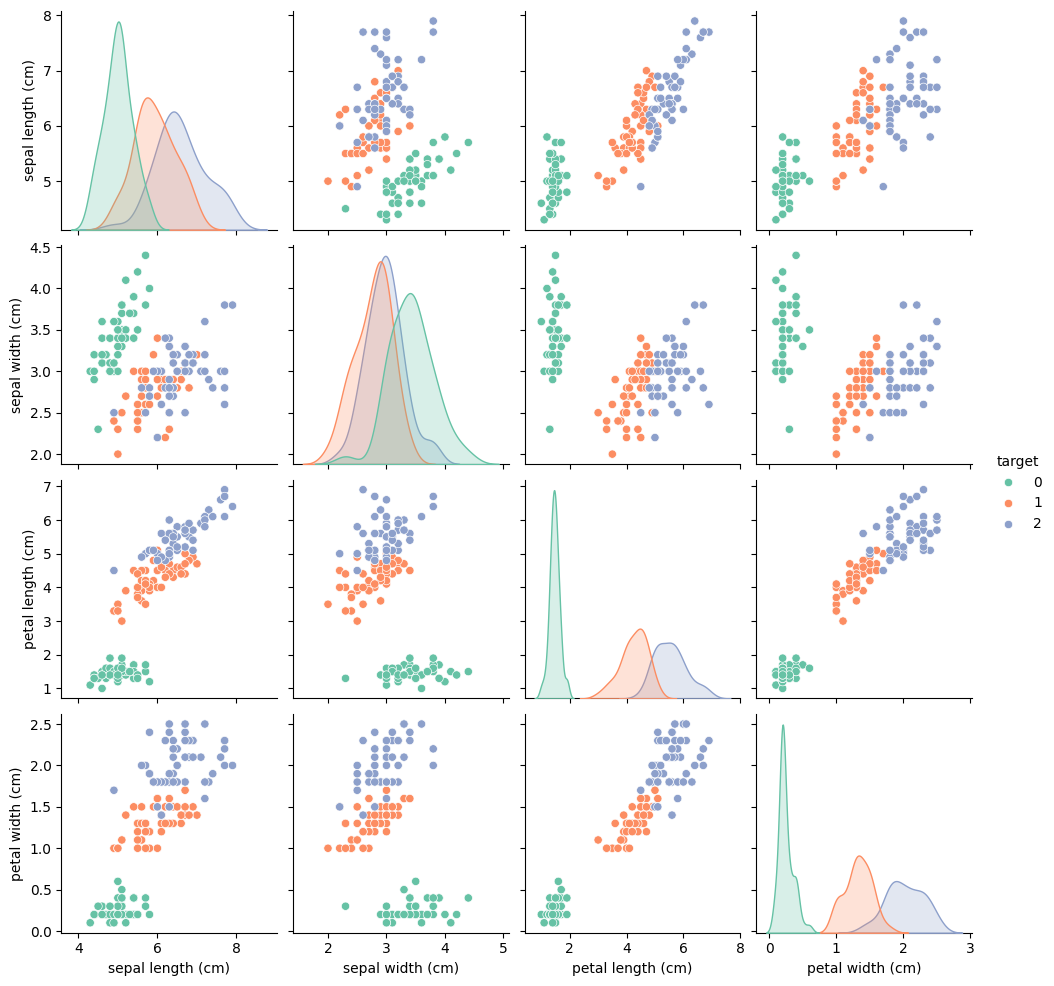

In [46]:
sns.pairplot(df, hue='target', palette='Set2')
plt.show()

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [47]:
X_sepal = X[['sepal length (cm)', 'sepal width (cm)']]

### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [48]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]

### Step 7. Initialize 2 `LogisticRegression` models

In [49]:
model_sepal = LogisticRegression()
model_petal = LogisticRegression()

### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [50]:

X_sepal_train, X_sepal_test, y_train, y_test = train_test_split(
    X_sepal, y, test_size=0.2, random_state=42, stratify=y
)

X_petal_train, X_petal_test, _, _ = train_test_split(
    X_petal, y, test_size=0.2, random_state=42, stratify=y
)

### Step 9.a Train both models

In [51]:
model_sepal.fit(X_sepal_train, y_train)
model_petal.fit(X_petal_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Step 10. Evaluate and compare both models

In [52]:
y_pred_sepal = model_sepal.predict(X_sepal_test)
y_pred_petal = model_petal.predict(X_petal_test)

acc_sepal = accuracy_score(y_test, y_pred_sepal)
acc_petal = accuracy_score(y_test, y_pred_petal)

print(f"Accuracy using Sepal features: {acc_sepal * 100:.2f}%")
print(f"Accuracy using Petal features: {acc_petal * 100:.2f}%")

Accuracy using Sepal features: 73.33%
Accuracy using Petal features: 96.67%


### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

#### Yes , This can be determined in two ways:

#### Digitally: The accuracy of the petal model is higher almost 97% , while the sepal model achieves much lower accuracy around 73% .

#### Visually: Based on the diagram we created in step 5, it was very clear that the points in the diagram (petal width with petal length) were well-spaced and separated into distinct groups, while the sepal points were heavily overlapping. 

### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

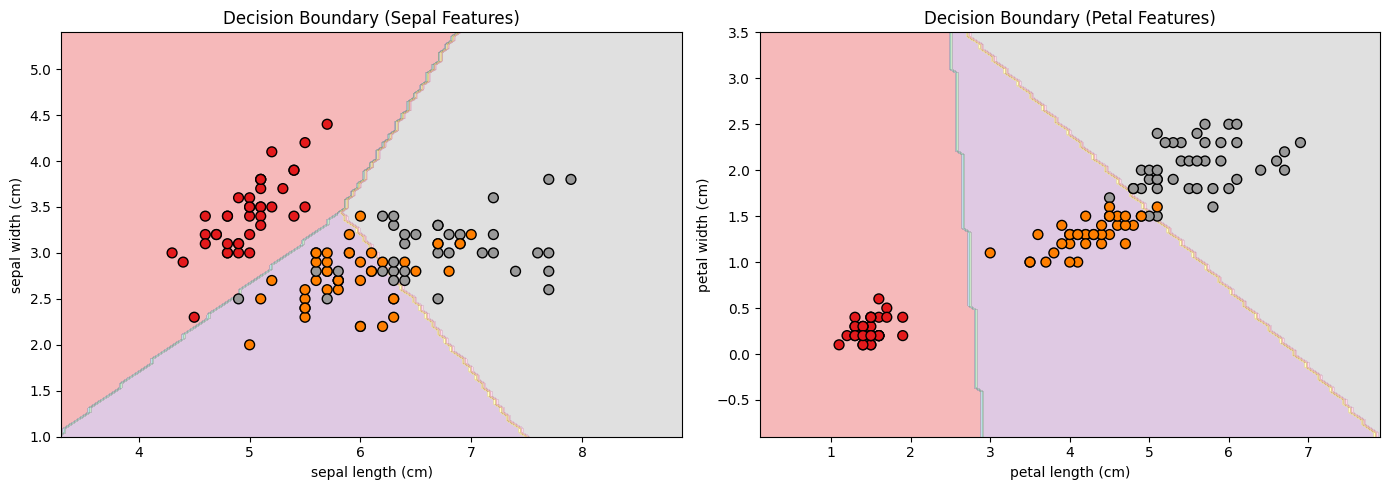

In [ ]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cmap_choice = "Set1"

DecisionBoundaryDisplay.from_estimator(
    model_sepal, X_sepal_train, response_method="predict",
    cmap=cmap_choice, alpha=0.3, ax=ax1  
)
ax1.scatter(
    X_sepal_train.iloc[:, 0], X_sepal_train.iloc[:, 1], 
    c=y_train, edgecolors='black', cmap=cmap_choice, s=50 
)
ax1.set_title("Decision Boundary (Sepal Features)")
ax1.set_xlabel("sepal length (cm)")
ax1.set_ylabel("sepal width (cm)")

DecisionBoundaryDisplay.from_estimator(
    model_petal, X_petal_train, response_method="predict",
    cmap=cmap_choice, alpha=0.3, ax=ax2
)
ax2.scatter(
    X_petal_train.iloc[:, 0], X_petal_train.iloc[:, 1], 
    c=y_train, edgecolors='black', cmap=cmap_choice, s=50
)
ax2.set_title("Decision Boundary (Petal Features)")
ax2.set_xlabel("petal length (cm)")
ax2.set_ylabel("petal width (cm)")

plt.tight_layout()
plt.show()